In [2]:
from google.colab import files
uploaded = files.upload()

Saving UNSW_NB15_testing-set.parquet to UNSW_NB15_testing-set.parquet
Saving UNSW_NB15_training-set.parquet to UNSW_NB15_training-set.parquet


In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
# This cell only contains import statements, which do not produce output when successful.

In [4]:
train_df = pd.read_parquet("UNSW_NB15_training-set.parquet")
test_df = pd.read_parquet("UNSW_NB15_testing-set.parquet")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (175341, 36)
Test shape: (82332, 36)


In [5]:
df = pd.concat([train_df, test_df], axis=0)

print("Combined shape:", df.shape)
df.head()

Combined shape: (257673, 36)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


# DATA Step 5: Data Cleaning

In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Identify categorical columns and convert them to object type to allow filling with 0
for col in df.select_dtypes(include='category').columns:
    df[col] = df[col].astype('object')

# Fill missing values
df = df.fillna(0)

print("After cleaning:", df.shape)

After cleaning: (145222, 36)


# Step 6: Check Target Column

In [7]:
df['label'].value_counts()

,count
label,
0,79965
1,65257


#Step 7: Encode Categorical Columns

In [8]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

#Step 8: Split Features & Target

In [9]:
X = df.drop('label', axis=1)
y = df['label']

#Step 9: Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (116177, 35)
Test: (29045, 35)


#Step 10: Feature Scaling

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#MODEL 1: Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

#MODEL 2: Decision Tree

In [13]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

#MODEL 3: Random Forest

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

#Step 11: Evaluation Function

In [16]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

#Step 12: Evaluate All Models

In [17]:
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Logistic Regression Results
Accuracy: 0.9198140815975211
Precision: 0.9223304639201663
Recall: 0.9198140815975211
F1 Score: 0.919299319310818

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93     16007
           1       0.95      0.86      0.91     13038

    accuracy                           0.92     29045
   macro avg       0.93      0.91      0.92     29045
weighted avg       0.92      0.92      0.92     29045


Decision Tree Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     16007
           1       1.00      1.00      1.00     13038

    accuracy                           1.00     29045
   macro avg       1.00      1.00      1.00     29045
weighted avg       1.00      1.00      1.00     29045


Random Forest Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1

#Step 13: Confusion Matrix (Best Model)

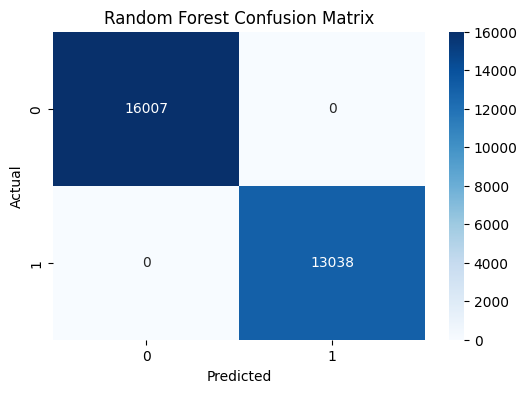

In [18]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Step 14: Feature Importance

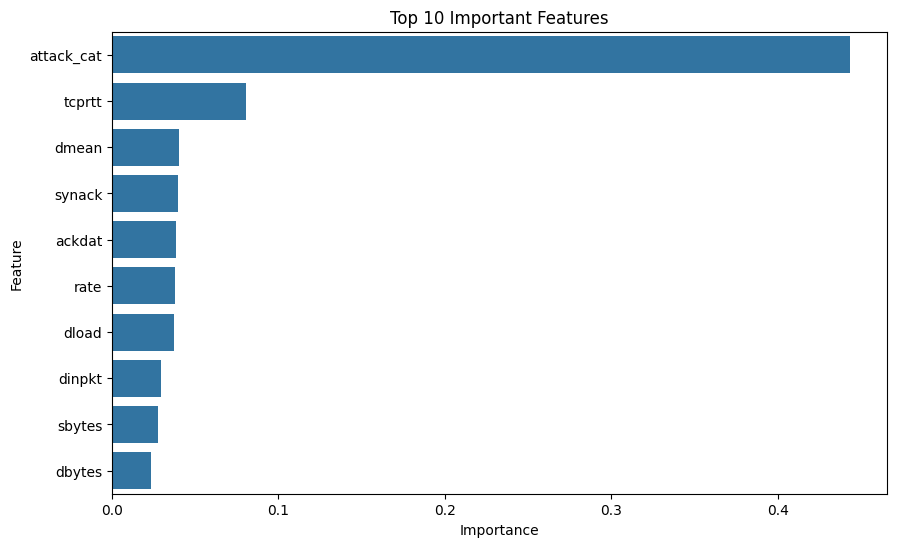

In [19]:
importance = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

#Step 15: Model Comparison Table

In [20]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average='weighted'),
        precision_score(y_test, dt_pred, average='weighted'),
        precision_score(y_test, rf_pred, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average='weighted'),
        recall_score(y_test, dt_pred, average='weighted'),
        recall_score(y_test, rf_pred, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, dt_pred, average='weighted'),
        f1_score(y_test, rf_pred, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.919814,0.92233,0.919814,0.919299
1,Decision Tree,1.000000,1.00000,1.000000,1.000000
2,Random Forest,1.000000,1.00000,1.000000,1.000000


#Step 16: Test Prediction

In [21]:
sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)

if prediction[0] == 0:
    print("Normal Traffic")
else:
    print("Attack Detected 🚨")

Attack Detected 🚨


In [22]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.9198140815975211
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0
